**Core Library Imports**

In [ ]:
#Core data handling
import pandas as pd
import numpy as np

#Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

#Statistical analysis
from statsmodels.tsa.stattools import acf

#Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

**Set Plot Style**

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

**Load the Dataset**

In [ ]:
#DATA LOADING and  INITIAL DATA CHECK

from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/datasets/hadukgrid_rainfall_2025.csv"


Mounted at /content/drive


In [ ]:
#Load dataset
df = pd.read_csv(file_path)
df.shape

(156088, 15)

In [ ]:
list(df.columns)

['time',
 'projection_y_coordinate',
 'projection_x_coordinate',
 'rainfall_mm',
 'latitude',
 'longitude',
 'day_of_year',
 'month',
 'week_of_year',
 'season',
 'rain_lag_1',
 'rain_lag_3',
 'rain_lag_7',
 'rain_rollsum_7',
 'rain_rollsum_30']

In [ ]:
#Convert time column to datetime
df["time"] = pd.to_datetime(df["time"])

#Convert categorical column
df["season"] = df["season"].astype("category")

#Ensure numeric columns are numeric
numeric_cols = [
    "rainfall_mm",
    "latitude",
    "longitude",
    "projection_x_coordinate",
    "projection_y_coordinate",
    "rain_lag_1",
    "rain_lag_3",
    "rain_lag_7",
    "rain_rollsum_7",
    "rain_rollsum_30",
    "day_of_year",
    "week_of_year",
    "month"
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

In [ ]:
#Sort by location (lat,lon) and time
df = df.sort_values(
    by=["latitude", "longitude", "time"]
).reset_index(drop=True)

print("Data sorted by spatial location and time")

Data sorted by spatial location and time


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156088 entries, 0 to 156087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   time                     156088 non-null  datetime64[ns]
 1   projection_y_coordinate  156088 non-null  float64       
 2   projection_x_coordinate  156088 non-null  float64       
 3   rainfall_mm              156088 non-null  float64       
 4   latitude                 156088 non-null  float64       
 5   longitude                156088 non-null  float64       
 6   day_of_year              156088 non-null  int64         
 7   month                    156088 non-null  int64         
 8   week_of_year             156088 non-null  int64         
 9   season                   156088 non-null  category      
 10  rain_lag_1               156088 non-null  float64       
 11  rain_lag_3               156088 non-null  float64       
 12  rain_lag_7      

In [ ]:
df.head()

,time,projection_y_coordinate,projection_x_coordinate,rainfall_mm,latitude,longitude,day_of_year,month,week_of_year,season,rain_lag_1,rain_lag_3,rain_lag_7,rain_rollsum_7,rain_rollsum_30
0,2025-01-08 12:00:00,37500.0,162500.0,10.528320,50.189194,-5.327663,8,1,2,Winter,1.245117,15.820312,13.156250,76.500000,89.656250
1,2025-01-09 12:00:00,37500.0,162500.0,4.671875,50.189194,-5.327663,9,1,2,Winter,10.528320,7.914062,0.057617,81.114258,94.328125
2,2025-01-10 12:00:00,37500.0,162500.0,3.799805,50.189194,-5.327663,10,1,2,Winter,4.671875,1.245117,0.398438,84.515625,98.127930
3,2025-01-11 12:00:00,37500.0,162500.0,2.021484,50.189194,-5.327663,11,1,2,Winter,3.799805,10.528320,40.536133,46.000977,100.149414
4,2025-01-12 12:00:00,37500.0,162500.0,0.019531,50.189194,-5.327663,12,1,2,Winter,2.021484,4.671875,15.820312,30.200195,100.168945


**Data Integrity & Quality Checks**

In [ ]:
#Check missing values per column
missing_summary = df.isnull().sum()

missing_summary

,0
time,0
projection_y_coordinate,0
projection_x_coordinate,0
rainfall_mm,0
latitude,0
longitude,0
day_of_year,0
month,0
week_of_year,0
season,0


In [ ]:
#Check duplicate rows
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(0)

In [ ]:
#Overall temporal coverage
df["time"].min(), df["time"].max()

(Timestamp('2025-01-08 12:00:00'), Timestamp('2025-12-31 12:00:00'))

In [ ]:
#Number of records per grid cell
records_per_location = (
    df.groupby(["latitude", "longitude"])
      .size()
      .describe()
)

records_per_location

,0
count,436.0
mean,358.0
std,0.0
min,358.0
25%,358.0
50%,358.0
75%,358.0
max,358.0


In [ ]:
#Basic rainfall validity checks
df["rainfall_mm"].describe()

,rainfall_mm
count,156088.000000
mean,2.839359
std,5.695600
min,0.000000
25%,0.006836
50%,0.314453
75%,3.008789
max,87.786133


In [ ]:
#Check for invalid rainfall values
(df["rainfall_mm"] < 0).sum()

np.int64(0)

In [ ]:
df[[
    "rain_lag_1",
    "rain_lag_3",
    "rain_lag_7",
    "rain_rollsum_7",
    "rain_rollsum_30"
]].describe()

,rain_lag_1,rain_lag_3,rain_lag_7,rain_rollsum_7,rain_rollsum_30
count,156088.000000,156088.000000,156088.000000,156088.000000,156088.000000
mean,2.836318,2.882898,2.920179,20.122179,84.199458
std,5.693996,5.763599,5.794955,23.247575,66.886195
min,0.000000,0.000000,0.000000,0.000000,0.015625
25%,0.006836,0.007812,0.008789,2.869141,35.120117
50%,0.313477,0.327148,0.352539,12.476562,65.067383
75%,3.001953,3.064453,3.135986,29.196289,115.654297
max,87.786133,87.786133,87.786133,229.845703,546.711914


**EDA(Exploratory Data Analysis)**

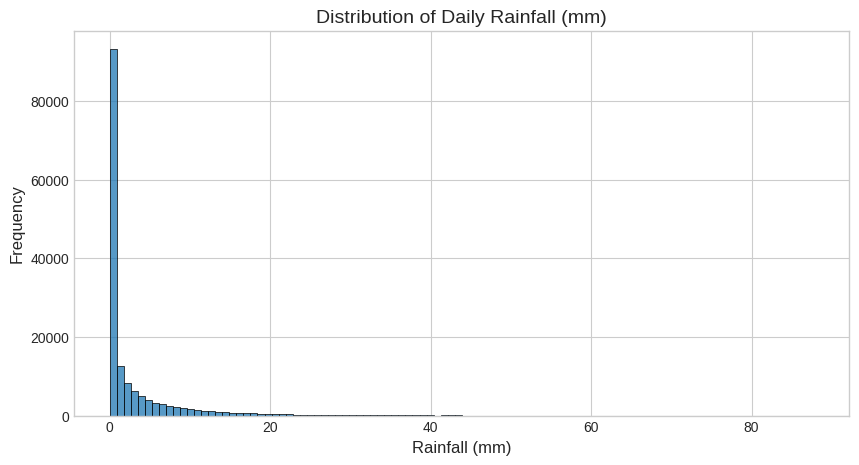

In [ ]:
#Histogram of daily rainfall
plt.figure()
sns.histplot(df["rainfall_mm"], bins=100, kde=False)
plt.title("Distribution of Daily Rainfall (mm)")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()

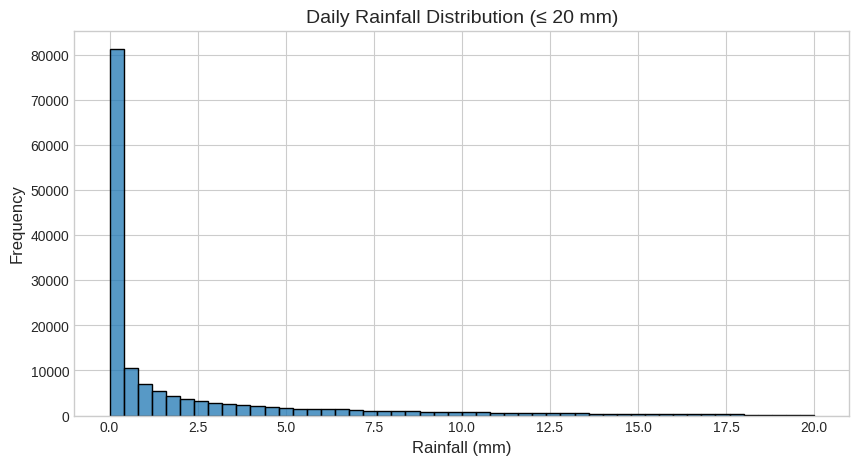

In [ ]:
#Focus on rainfall <= 20 mm
plt.figure()
sns.histplot(df[df["rainfall_mm"] <= 20]["rainfall_mm"], bins=50)
plt.title("Daily Rainfall Distribution (≤ 20 mm)")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()

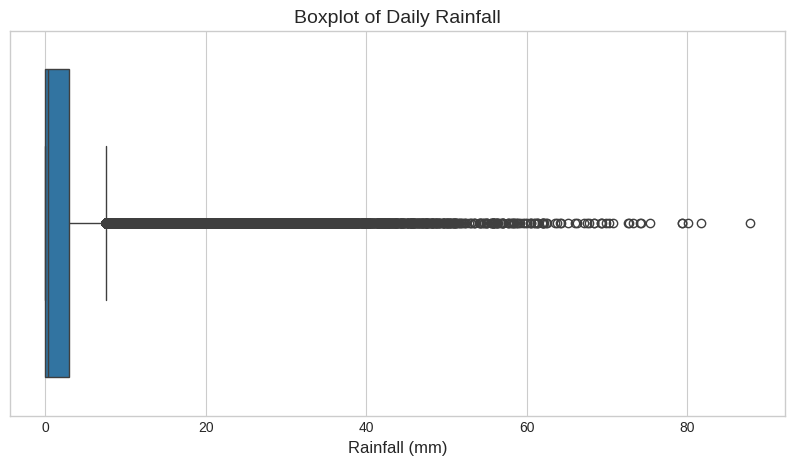

In [ ]:
plt.figure()
sns.boxplot(x=df["rainfall_mm"])
plt.title("Boxplot of Daily Rainfall")
plt.xlabel("Rainfall (mm)")
plt.show()

In [ ]:
#Percentage of dry days
zero_rain_pct = (df["rainfall_mm"] == 0).mean() * 100
zero_rain_pct

np.float64(15.842345343652298)

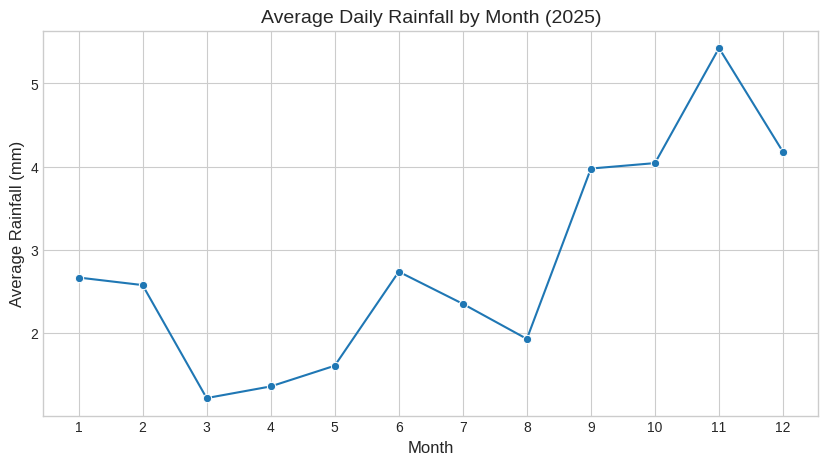

In [ ]:
#Monthly average rainfall
monthly_avg = (
    df.groupby("month")["rainfall_mm"]
      .mean()
      .reset_index()
)

plt.figure()
sns.lineplot(data=monthly_avg, x="month", y="rainfall_mm", marker="o")
plt.title("Average Daily Rainfall by Month (2025)")
plt.xlabel("Month")
plt.ylabel("Average Rainfall (mm)")
plt.xticks(range(1, 13))
plt.show()

/tmp/ipykernel_1544/2828595351.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("season")["rainfall_mm"]


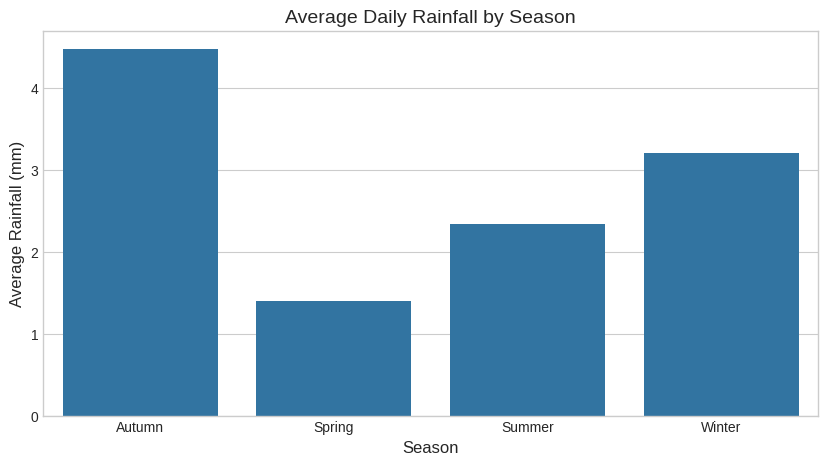

In [ ]:
#Seasonal average rainfall
seasonal_avg = (
    df.groupby("season")["rainfall_mm"]
      .mean()
      .reset_index()
)

plt.figure()
sns.barplot(data=seasonal_avg, x="season", y="rainfall_mm")
plt.title("Average Daily Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Average Rainfall (mm)")
plt.show()

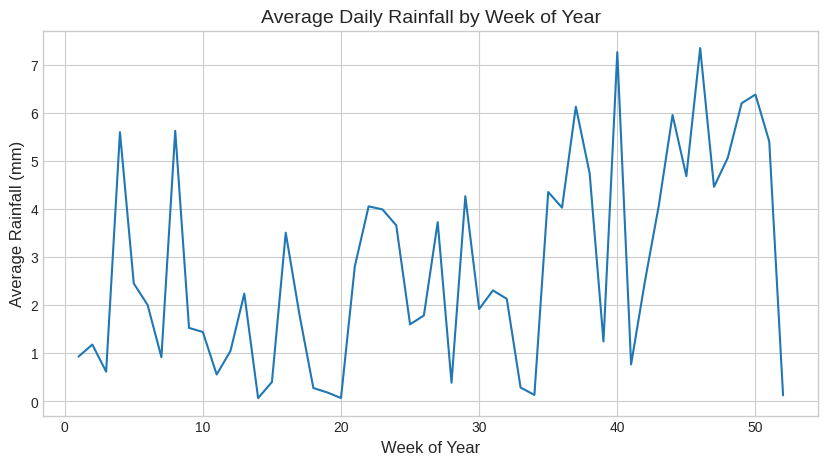

In [ ]:
weekly_avg = (
    df.groupby("week_of_year")["rainfall_mm"]
      .mean()
      .reset_index()
)

plt.figure()
sns.lineplot(data=weekly_avg, x="week_of_year", y="rainfall_mm")
plt.title("Average Daily Rainfall by Week of Year")
plt.xlabel("Week of Year")
plt.ylabel("Average Rainfall (mm)")
plt.show()

In [ ]:
spatial_mean = (
    df.groupby(["latitude", "longitude"])["rainfall_mm"]
      .mean()
      .reset_index()
)

spatial_mean.describe()

,latitude,longitude,rainfall_mm
count,436.000000,436.000000,436.000000
mean,54.129810,-2.939201,2.839359
std,2.366055,2.106004,1.459657
min,50.189194,-7.999914,1.045099
25%,52.034215,-4.321046,1.680779
50%,54.048415,-2.947188,2.408780
75%,55.899973,-1.441295,3.616737
max,60.569832,1.530286,8.142938


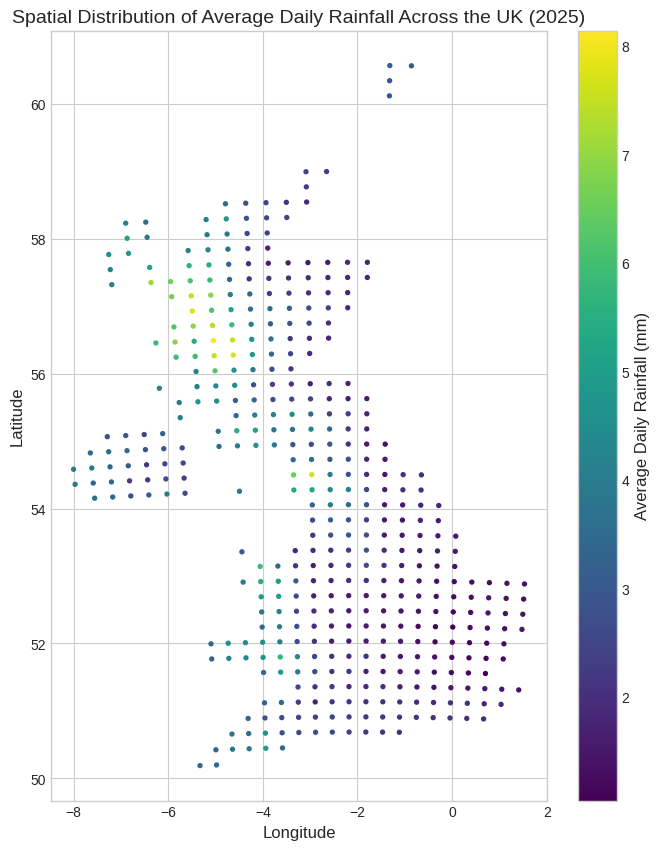

In [ ]:
plt.figure(figsize=(8, 10))
plt.scatter(
    spatial_mean["longitude"],
    spatial_mean["latitude"],
    c=spatial_mean["rainfall_mm"],
    cmap="viridis",
    s=8
)
plt.colorbar(label="Average Daily Rainfall (mm)")
plt.title("Spatial Distribution of Average Daily Rainfall Across the UK (2025)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [ ]:
spatial_mean["latitude"].corr(spatial_mean["rainfall_mm"])

np.float64(0.3639102659394039)

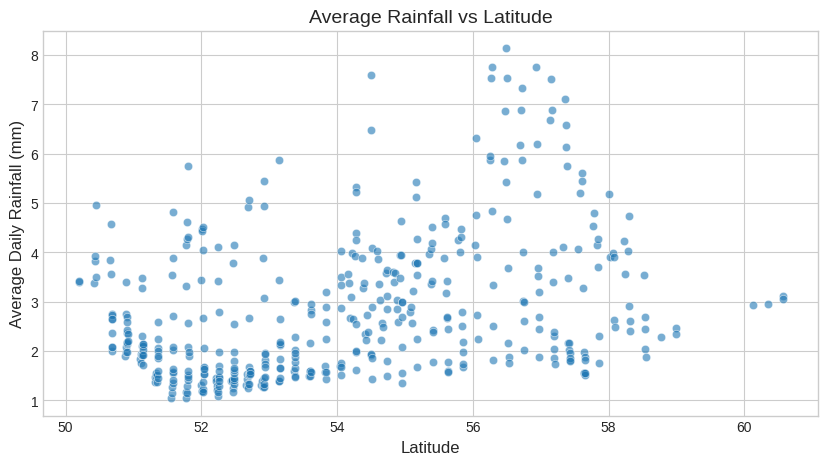

In [ ]:
plt.figure()
sns.scatterplot(
    x=spatial_mean["latitude"],
    y=spatial_mean["rainfall_mm"],
    alpha=0.6
)
plt.title("Average Rainfall vs Latitude")
plt.xlabel("Latitude")
plt.ylabel("Average Daily Rainfall (mm)")
plt.show()

In [ ]:
df["lat_band"] = pd.cut(df["latitude"], bins=5)

lat_band_stats = (
    df.groupby("lat_band")["rainfall_mm"]
      .mean()
      .reset_index()
)

lat_band_stats

/tmp/ipykernel_1544/673290587.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("lat_band")["rainfall_mm"]


,lat_band,rainfall_mm
0,"(50.179, 52.265]",2.308627
1,"(52.265, 54.341]",2.281256
2,"(54.341, 56.418]",3.332107
3,"(56.418, 58.494]",3.839634
4,"(58.494, 60.57]",2.643610


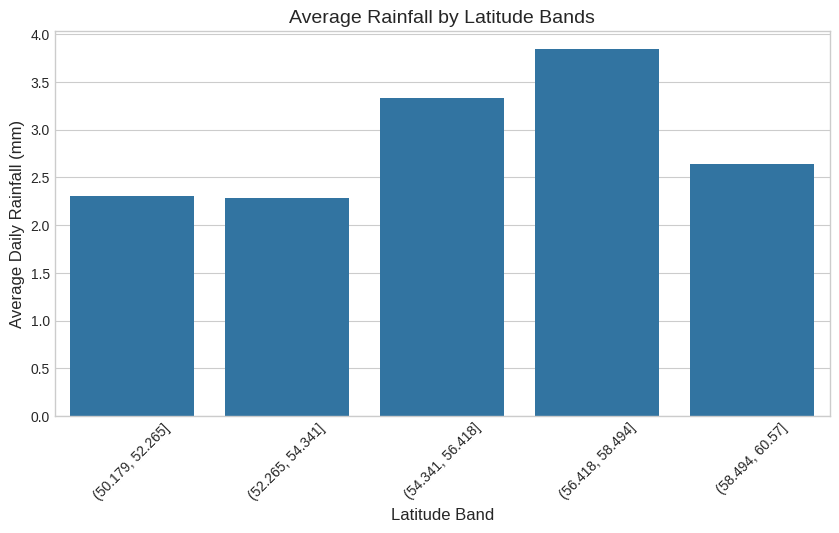

In [ ]:
plt.figure()
sns.barplot(data=lat_band_stats, x="lat_band", y="rainfall_mm")
plt.title("Average Rainfall by Latitude Bands")
plt.xlabel("Latitude Band")
plt.ylabel("Average Daily Rainfall (mm)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Correlation of target with persistence features
features = [
    "rain_lag_1",
    "rain_lag_3",
    "rain_lag_7",
    "rain_rollsum_7",
    "rain_rollsum_30"
]

corr_with_target = df[features + ["rainfall_mm"]].corr()["rainfall_mm"].sort_values(ascending=False)
corr_with_target

,rainfall_mm
rainfall_mm,1.000000
rain_rollsum_7,0.525020
rain_rollsum_30,0.348417
rain_lag_1,0.337718
rain_lag_3,0.207322
rain_lag_7,0.103298


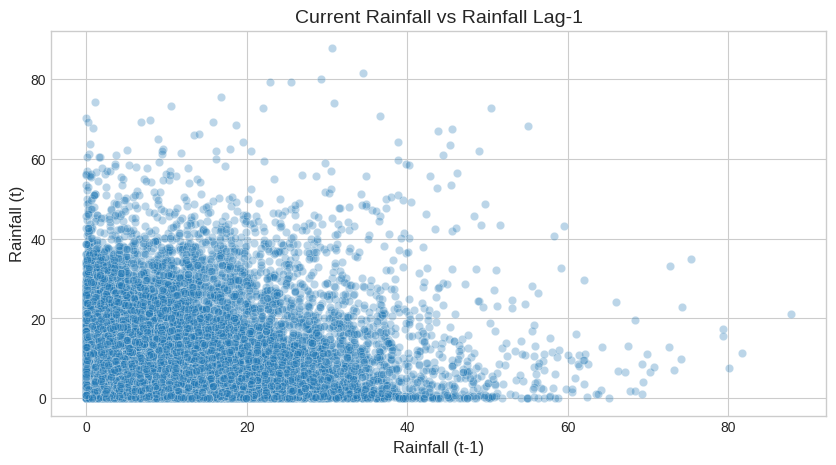

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.scatterplot(x=df["rain_lag_1"], y=df["rainfall_mm"], alpha=0.3)
plt.title("Current Rainfall vs Rainfall Lag-1")
plt.xlabel("Rainfall (t-1)")
plt.ylabel("Rainfall (t)")
plt.show()

Skewness: 3.7107278867779763
Kurtosis: 19.87253080026435


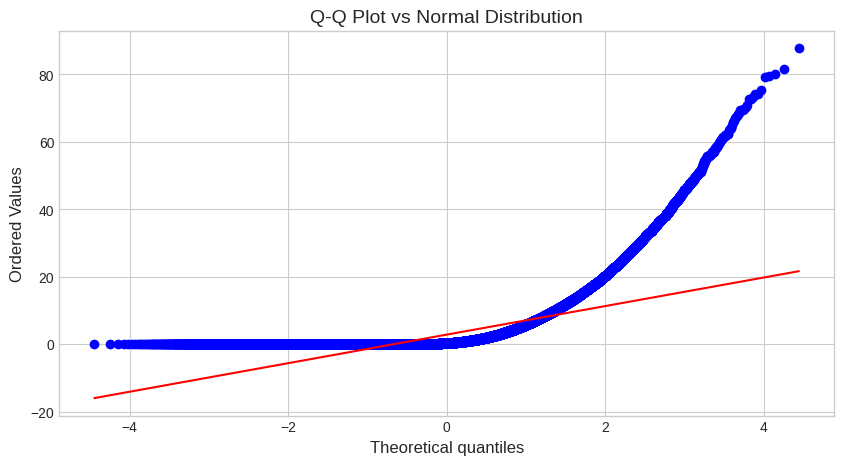

In [ ]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

rain = df["rainfall_mm"]

print("Skewness:", stats.skew(rain))
print("Kurtosis:", stats.kurtosis(rain))

# Q-Q Plot
stats.probplot(rain, dist="norm", plot=plt)
plt.title("Q-Q Plot vs Normal Distribution")
plt.show()

In [ ]:
zero_ratio = (df["rainfall_mm"] == 0).mean()
print("Zero ratio:", zero_ratio)

# Consecutive dry days
df["is_zero"] = (df["rainfall_mm"] == 0).astype(int)
dry_streaks = df.groupby("projection_y_coordinate")["is_zero"].sum()
print("Average dry days per grid:", dry_streaks.mean())

Zero ratio: 0.15842345343652298
Average dry days per grid: 575.0697674418604


In [ ]:
from statsmodels.tsa.stattools import adfuller

daily_mean = df.groupby("time")["rainfall_mm"].mean()

result = adfuller(daily_mean)
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -6.983725877474057
p-value: 8.068434311715027e-10


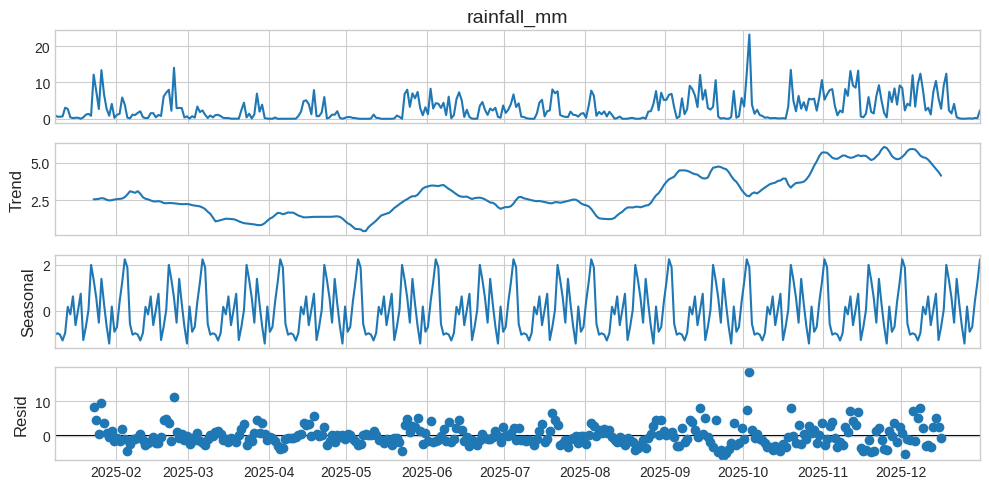

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(daily_mean, model='additive', period=30)
decomposition.plot()
plt.show()

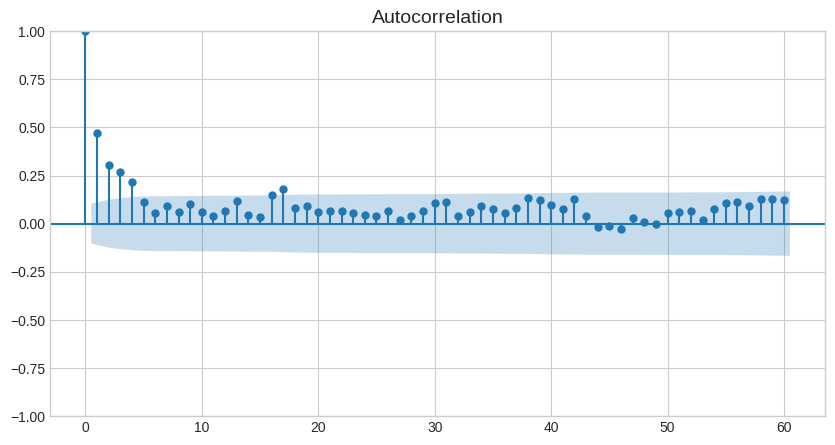

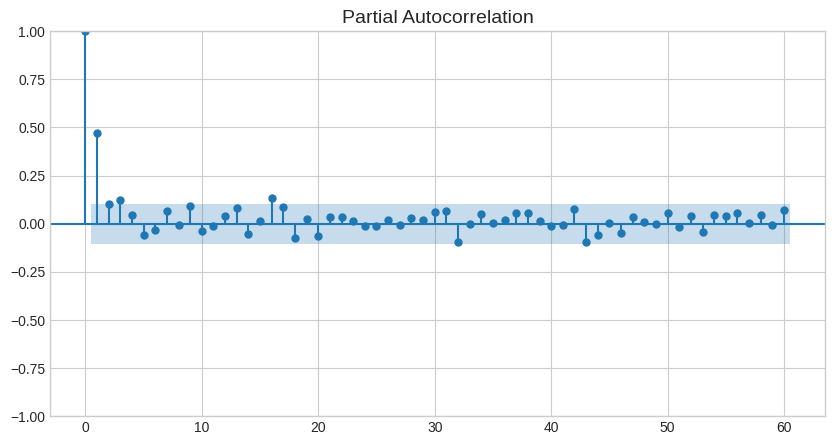

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(daily_mean, lags=60)
plt.show()

plot_pacf(daily_mean, lags=60)
plt.show()

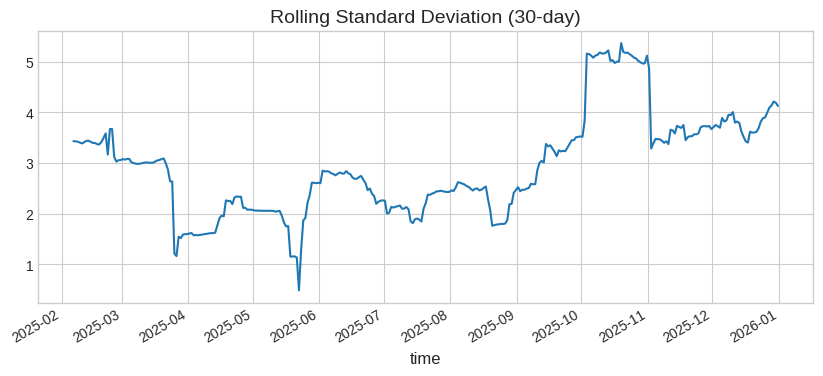

In [ ]:
rolling_std = daily_mean.rolling(30).std()

plt.figure(figsize=(10,4))
rolling_std.plot()
plt.title("Rolling Standard Deviation (30-day)")
plt.show()

In [ ]:
threshold = np.percentile(rain, 95)
extreme_values = rain[rain > threshold]

print("95th percentile threshold:", threshold)
print("Number of extreme events:", len(extreme_values))

95th percentile threshold: 13.9990234375
Number of extreme events: 7804


In [ ]:
shape, loc, scale = stats.genpareto.fit(extreme_values)
print("GPD shape:", shape)

GPD shape: 0.03984745691314008


In [ ]:
spatial_mean = df.groupby(
    ["projection_y_coordinate", "projection_x_coordinate"]
)["rainfall_mm"].mean()

print("Spatial variance:", spatial_mean.var())

Spatial variance: 2.13059916998408


In [ ]:
from sklearn.feature_selection import mutual_info_regression

X = df[[
    "rain_lag_1",
    "rain_lag_3",
    "rain_lag_7",
    "rain_rollsum_7",
    "rain_rollsum_30"
]]
y = df["rainfall_mm"]

mi = mutual_info_regression(X, y)

for col, val in zip(X.columns, mi):
    print(col, ":", val)

rain_lag_1 : 0.20992437101829786
rain_lag_3 : 0.07174907915798023
rain_lag_7 : 0.019690214478609747
rain_rollsum_7 : 0.3372049744660659
rain_rollsum_30 : 0.11711092427650804


In [ ]:
lag_corr = daily_mean.autocorr(lag=7)
print("7-day autocorrelation:", lag_corr)

7-day autocorrelation: 0.09360626373653655


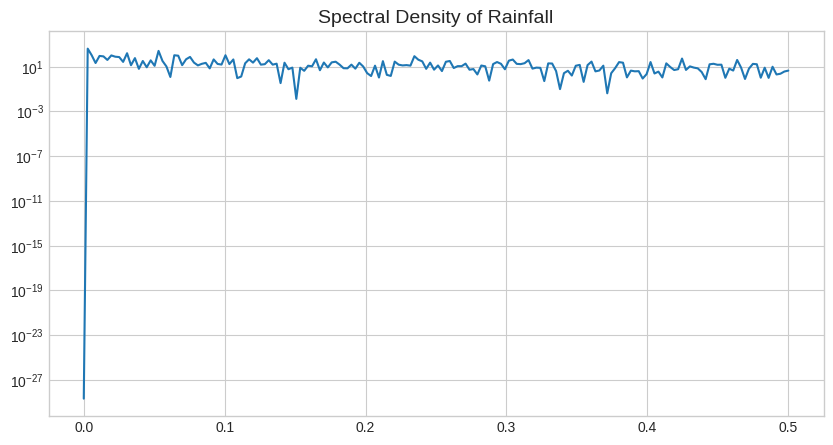

In [ ]:
from scipy.signal import periodogram

freqs, power = periodogram(daily_mean)

plt.semilogy(freqs, power)
plt.title("Spectral Density of Rainfall")
plt.show()

**DATA PRE-PROCESSING**

In [ ]:
# Convert time column
df["time"] = pd.to_datetime(df["time"])

# Sort properly
df = df.sort_values(
    ["time", "projection_y_coordinate", "projection_x_coordinate"]
).reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["time"].min(), "to", df["time"].max())
print("Missing values:\n", df.isnull().sum())

# Check duplicates
assert df.duplicated(
    subset=["time","projection_y_coordinate","projection_x_coordinate"]
).sum() == 0, "Duplicate rows found!"

Shape: (156088, 17)
Date range: 2025-01-08 12:00:00 to 2025-12-31 12:00:00
Missing values:
 time                       0
projection_y_coordinate    0
projection_x_coordinate    0
rainfall_mm                0
latitude                   0
longitude                  0
day_of_year                0
month                      0
week_of_year               0
season                     0
rain_lag_1                 0
rain_lag_3                 0
rain_lag_7                 0
rain_rollsum_7             0
rain_rollsum_30            0
lat_band                   0
is_zero                    0
dtype: int64


In [ ]:
df["rain_log"] = np.log1p(df["rainfall_mm"])

In [ ]:
# Day of year
df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

# Month
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Drop raw temporal columns
df = df.drop(columns=["day_of_year","month"])

In [ ]:
FEATURE_COLUMNS = [
    "rain_log",
    "rain_lag_1",
    "rain_lag_3",
    "rain_lag_7",
    "rain_rollsum_7",
    "rain_rollsum_30",
    "doy_sin",
    "doy_cos",
    "month_sin",
    "month_cos"
]

In [ ]:
train_end = df["time"].quantile(0.70)
val_end   = df["time"].quantile(0.85)

train_df = df[df["time"] <= train_end].copy()
val_df   = df[(df["time"] > train_end) & (df["time"] <= val_end)].copy()
test_df  = df[df["time"] > val_end].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (109436, 20)
Validation shape: (23544, 20)
Test shape: (23108, 20)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Fit only on training
train_df[FEATURE_COLUMNS] = scaler.fit_transform(train_df[FEATURE_COLUMNS])

# Transform validation & test
val_df[FEATURE_COLUMNS] = scaler.transform(val_df[FEATURE_COLUMNS])
test_df[FEATURE_COLUMNS] = scaler.transform(test_df[FEATURE_COLUMNS])

In [ ]:
# Check NaNs
assert train_df[FEATURE_COLUMNS].isnull().sum().sum() == 0
assert val_df[FEATURE_COLUMNS].isnull().sum().sum() == 0
assert test_df[FEATURE_COLUMNS].isnull().sum().sum() == 0

# Check infinite values
assert np.isinf(train_df[FEATURE_COLUMNS].values).sum() == 0

print("Preprocessing completed successfully.")

Preprocessing completed successfully.


In [ ]:
train_df.to_csv("train_processed.csv", index=False)
val_df.to_csv("val_processed.csv", index=False)
test_df.to_csv("test_processed.csv", index=False)

**FEATURE ENGINEERING**

In [ ]:
df = df.sort_values(
    ["projection_y_coordinate",
     "projection_x_coordinate",
     "time"]
).reset_index(drop=True)

In [ ]:
df["rain_log"] = np.log1p(df["rainfall_mm"])

In [ ]:
df["grid_id"] = df["projection_y_coordinate"].astype(str) + "_" + df["projection_x_coordinate"].astype(str)
for lag in [1, 3, 7, 14]:
    df[f"lag_{lag}"] = df.groupby("grid_id")["rain_log"].shift(lag)

In [ ]:
df["roll_mean_7"] = df.groupby("grid_id")["rain_log"] \
                        .rolling(7).mean().reset_index(0, drop=True)

df["roll_sum_7"] = df.groupby("grid_id")["rain_log"] \
                       .rolling(7).sum().reset_index(0, drop=True)

df["roll_std_7"] = df.groupby("grid_id")["rain_log"] \
                       .rolling(7).std().reset_index(0, drop=True)

df["roll_mean_30"] = df.groupby("grid_id")["rain_log"] \
                         .rolling(30).mean().reset_index(0, drop=True)

df["roll_sum_30"] = df.groupby("grid_id")["rain_log"] \
                        .rolling(30).sum().reset_index(0, drop=True)

In [ ]:
df["wet_day"] = (df["rainfall_mm"] > 0).astype(int)

df["wet_streak_7"] = df.groupby("grid_id")["wet_day"] \
                          .rolling(7).sum().reset_index(0, drop=True)

In [ ]:
threshold = df["rainfall_mm"].quantile(0.95)

df["extreme_flag"] = (df["rainfall_mm"] > threshold).astype(int)

In [ ]:
df["relative_intensity"] = df["rain_log"] / (df["roll_mean_30"] + 1e-6)

In [ ]:
df["day_of_year"] = df["time"].dt.dayofyear
df["month"] = df["time"].dt.month

df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df = df.drop(columns=["day_of_year", "month"])

In [ ]:
df["lat_norm"] = (df["latitude"] - df["latitude"].min()) / \
                 (df["latitude"].max() - df["latitude"].min())

df["lon_norm"] = (df["longitude"] - df["longitude"].min()) / \
                 (df["longitude"].max() - df["longitude"].min())

In [ ]:
df = df.dropna().reset_index(drop=True)

In [ ]:
FINAL_FEATURES = [
    "rain_log",
    "lag_1",
    "lag_3",
    "lag_7",
    "lag_14",
    "roll_mean_7",
    "roll_sum_7",
    "roll_std_7",
    "roll_mean_30",
    "roll_sum_30",
    "wet_streak_7",
    "relative_intensity",
    "doy_sin",
    "doy_cos",
    "month_sin",
    "month_cos",
    "lat_norm",
    "lon_norm"
]

In [ ]:
print("Final dataset shape:", df.shape)
print("Missing values:", df[FINAL_FEATURES].isnull().sum().sum())

Final dataset shape: (143444, 36)
Missing values: 0


**ConvLSTM**

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [ ]:
df["time"] = pd.to_datetime(df["time"])

df = df.sort_values(
    ["projection_y_coordinate",
     "projection_x_coordinate",
     "time"]
).reset_index(drop=True)

In [ ]:
df["rain_log"] = np.log1p(df["rainfall_mm"])

df["grid_id"] = (
    df["projection_y_coordinate"].astype(str) + "_" +
    df["projection_x_coordinate"].astype(str)
)

# Lag features
for lag in [1, 3, 7, 14]:
    df[f"lag_{lag}"] = df.groupby("grid_id")["rain_log"].shift(lag)

# Rolling features
df["roll_mean_7"] = df.groupby("grid_id")["rain_log"] \
    .rolling(7).mean().reset_index(0, drop=True)

df["roll_std_7"] = df.groupby("grid_id")["rain_log"] \
    .rolling(7).std().reset_index(0, drop=True)

df["roll_mean_30"] = df.groupby("grid_id")["rain_log"] \
    .rolling(30).mean().reset_index(0, drop=True)

# Re-extract day_of_year and month before cyclical encoding
df["day_of_year"] = df["time"].dt.dayofyear
df["month"] = df["time"].dt.month

# Cyclical encoding
df["doy_sin"] = np.sin(2*np.pi*df["day_of_year"]/365)
df["doy_cos"] = np.cos(2*np.pi*df["day_of_year"]/365)
df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
df["month_cos"] = np.cos(2*np.pi*df["month"]/12)

df = df.dropna().reset_index(drop=True)

In [ ]:
FEATURES = [
    "rain_log",
    "lag_1","lag_3","lag_7","lag_14",
    "roll_mean_7","roll_std_7","roll_mean_30",
    "doy_sin","doy_cos"
]

In [ ]:
train_end = df["time"].quantile(0.70)
val_end   = df["time"].quantile(0.85)

train_df = df[df["time"] <= train_end].copy()
val_df   = df[(df["time"] > train_end) & (df["time"] <= val_end)].copy()
test_df  = df[df["time"] > val_end].copy()

In [ ]:
scaler = MinMaxScaler()

train_df[FEATURES] = scaler.fit_transform(train_df[FEATURES])
val_df[FEATURES]   = scaler.transform(val_df[FEATURES])
test_df[FEATURES]  = scaler.transform(test_df[FEATURES])

In [ ]:
y_unique = np.sort(df["projection_y_coordinate"].unique())
x_unique = np.sort(df["projection_x_coordinate"].unique())

H = len(y_unique)
W = len(x_unique)

y_index = {v:i for i,v in enumerate(y_unique)}
x_index = {v:i for i,v in enumerate(x_unique)}

In [ ]:
def build_daily_tensor(sub_df):
    tensors = []
    dates = sorted(sub_df["time"].unique())

    for date in dates:
        day_data = sub_df[sub_df["time"] == date]
        grid = np.zeros((H, W, len(FEATURES)))

        for _, row in day_data.iterrows():
            yi = y_index[row["projection_y_coordinate"]]
            xi = x_index[row["projection_x_coordinate"]]
            grid[yi, xi, :] = row[FEATURES].values

        tensors.append(grid)

    return np.array(tensors)

In [ ]:
X_train_days = build_daily_tensor(train_df)
X_val_days   = build_daily_tensor(val_df)
X_test_days  = build_daily_tensor(test_df)

In [ ]:
LOOKBACK = 14

def create_windows(X):
    X_seq, y_seq = [], []

    for i in range(LOOKBACK, len(X)):
        X_seq.append(X[i-LOOKBACK:i])
        y_seq.append(X[i,:,:,0])

    return np.array(X_seq), np.array(y_seq)

X_train, y_train = create_windows(X_train_days)
X_val, y_val     = create_windows(X_val_days)
X_test, y_test   = create_windows(X_test_days)

y_train = y_train[..., np.newaxis]
y_val   = y_val[..., np.newaxis]
y_test  = y_test[..., np.newaxis]

In [ ]:
model = Sequential()

model.add(ConvLSTM2D(
    filters=64,
    kernel_size=(3,3),
    padding="same",
    return_sequences=True,
    input_shape=(LOOKBACK, H, W, len(FEATURES))
))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(ConvLSTM2D(
    filters=32,
    kernel_size=(3,3),
    padding="same",
    return_sequences=False
))
model.add(BatchNormalization())

model.add(Conv2D(
    filters=1,
    kernel_size=(1,1),
    activation="linear",
    padding="same"
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
early_stop = EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3)


model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=4,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - loss: 0.2882 - mae: 0.3264 - val_loss: 0.0382 - val_mae: 0.1336 - learning_rate: 0.0010
Epoch 2/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0349 - mae: 0.1390 - val_loss: 0.0518 - val_mae: 0.1490 - learning_rate: 0.0010
Epoch 3/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0269 - mae: 0.1189 - val_loss: 0.0522 - val_mae: 0.1506 - learning_rate: 0.0010
Epoch 4/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 0.0234 - mae: 0.1083 - val_loss: 0.0446 - val_mae: 0.1438 - learning_rate: 0.0010
Epoch 5/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.0211 - mae: 0.1022 - val_loss: 0.0432 - val_mae: 0.1394 - learning_rate: 5.0000e-04
Epoch 6/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.0203 - mae: 0.0989 - val_loss: 0.0390 - val_mae: 0.1415 - learning_rate: 5.0000e-04
Epoch 7/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.0197 - mae: 0.0960 - val_loss: 0.0356 - val_mae: 0.1377 - learning_rate: 5.0000e-04

In [ ]:
pred = model.predict(X_test)

y_true_flat = y_test.flatten()
y_pred_flat = pred.flatten()

dummy = np.zeros((len(y_pred_flat), len(FEATURES)))

dummy[:,0] = y_pred_flat
inv_pred = scaler.inverse_transform(dummy)[:,0]

dummy[:,0] = y_true_flat
inv_true = scaler.inverse_transform(dummy)[:,0]

pred_mm = np.expm1(inv_pred)
true_mm = np.expm1(inv_true)

mae = mean_absolute_error(true_mm, pred_mm)
rmse = np.sqrt(mean_squared_error(true_mm, pred_mm))
r2 = r2_score(true_mm, pred_mm)

print("MAE (mm):", mae)
print("RMSE (mm):", rmse)
print("R2:", r2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
MAE (mm): 1.5040771896260419
RMSE (mm): 4.219134129615781
R2: 0.22764954691964978


In [ ]:
threshold = np.percentile(true_mm, 95)
mask = true_mm > threshold

mae_extreme = mean_absolute_error(true_mm[mask], pred_mm[mask])

print("Extreme MAE (mm):", mae_extreme)

Extreme MAE (mm): 15.207843962165148


**TCN**

In [ ]:
import numpy as np

LOOKBACK = 14

def create_tcn_sequences(sub_df):
    X_list = []
    y_list = []

    for grid_id, group in sub_df.groupby("grid_id"):
        group = group.sort_values("time")

        values = group[FEATURES].values

        for i in range(LOOKBACK, len(values)):
            X_list.append(values[i-LOOKBACK:i])
            y_list.append(values[i, 0])  # rain_log target

    return np.array(X_list), np.array(y_list)

In [ ]:
X_train_tcn, y_train_tcn = create_tcn_sequences(train_df)
X_val_tcn, y_val_tcn     = create_tcn_sequences(val_df)
X_test_tcn, y_test_tcn   = create_tcn_sequences(test_df)

print("Train shape:", X_train_tcn.shape)

Train shape: (85456, 14, 10)


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
def tcn_block(x, filters, dilation_rate):
    x = Conv1D(filters=filters,
               kernel_size=3,
               padding="causal",
               dilation_rate=dilation_rate,
               activation="relu")(x)
    x = BatchNormalization()(x)
    return x

In [ ]:
inputs = Input(shape=(LOOKBACK, len(FEATURES)))

x = tcn_block(inputs, 64, 1)
x = tcn_block(x, 64, 2)
x = tcn_block(x, 64, 4)
x = tcn_block(x, 64, 8)

x = tf.keras.layers.GlobalAveragePooling1D()(x)

x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)

outputs = Dense(1, activation="linear")(x)

tcn_model = Model(inputs, outputs)

tcn_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

tcn_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 14, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 14, 64)         │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 14, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 14, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 14, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,289 (173.00 KB)

 Trainable params: 43,777 (171.00 KB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_tcn = tcn_model.fit(
    X_train_tcn, y_train_tcn,
    validation_data=(X_val_tcn, y_val_tcn),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/30
668/668 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 0.0273 - mae: 0.1206 - val_loss: 0.0749 - val_mae: 0.2250
Epoch 2/30
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0163 - mae: 0.0919 - val_loss: 0.0764 - val_mae: 0.2223
Epoch 3/30
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0133 - mae: 0.0819 - val_loss: 0.0799 - val_mae: 0.2361
Epoch 4/30
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0117 - mae: 0.0764 - val_loss: 0.0727 - val_mae: 0.2218
Epoch 5/30
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0105 - mae: 0.0717 - val_loss: 0.0730 - val_mae: 0.2232
Epoch 6/30
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0097 - mae: 0.0690 - val_loss: 0.0718 - val_mae: 0.2183
Epoch 7/30
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0091 - mae: 0.0668 - val_loss: 0.0754 - val_mae: 0.2226
Epoch 8/30
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0086 - mae: 0.0646 - val_loss: 0.0750 - val_mae: 0.2282
Epoch 9/30
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - 

In [ ]:
pred_tcn = tcn_model.predict(X_test_tcn).flatten()

mae_log = mean_absolute_error(y_test_tcn, pred_tcn)
rmse_log = np.sqrt(mean_squared_error(y_test_tcn, pred_tcn))
r2_log = r2_score(y_test_tcn, pred_tcn)

print("TCN MAE (log):", mae_log)
print("TCN RMSE (log):", rmse_log)
print("TCN R2 (log):", r2_log)

423/423 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
TCN MAE (log): 0.22710264636722804
TCN RMSE (log): 0.26074223000045604
TCN R2 (log): -0.13797996432126092


In [ ]:
# inverse scaling
dummy_full = np.zeros((len(pred_tcn), len(FEATURES)))

dummy_full[:,0] = pred_tcn
inv_pred = scaler.inverse_transform(dummy_full)[:,0]

dummy_full[:,0] = y_test_tcn
inv_true = scaler.inverse_transform(dummy_full)[:,0]

pred_mm = np.expm1(inv_pred)
true_mm = np.expm1(inv_true)

mae_mm = mean_absolute_error(true_mm, pred_mm)
rmse_mm = np.sqrt(mean_squared_error(true_mm, pred_mm))
r2_mm = r2_score(true_mm, pred_mm)

print("TCN MAE (mm):", mae_mm)
print("TCN RMSE (mm):", rmse_mm)
print("TCN R2 (mm):", r2_mm)

TCN MAE (mm): 4.38072991280424
TCN RMSE (mm): 7.147679365911508
TCN R2 (mm): -0.05423101177782952


In [ ]:
threshold = np.percentile(true_mm, 95)
mask = true_mm > threshold

mae_extreme = mean_absolute_error(true_mm[mask], pred_mm[mask])
print("TCN Extreme MAE:", mae_extreme)

TCN Extreme MAE: 23.61917581688511


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
423/423 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

Model Comparison Table:


,Model,MAE_mm,RMSE_mm,R2,Extreme_MAE_mm,MAE_Rank,RMSE_Rank,R2_Rank,Extreme_MAE_Rank
0,ConvLSTM,1.5041,4.2191,0.2276,15.2078,1.0,1.0,1.0,1.0
1,TCN,4.3807,7.1477,-0.0542,23.6192,2.0,2.0,2.0,2.0



Final Report Table:


,Model,MAE (mm),RMSE (mm),R²,Extreme Event MAE (mm)
0,ConvLSTM,1.5041,4.2191,0.2276,15.2078
1,TCN,4.3807,7.1477,-0.0542,23.6192


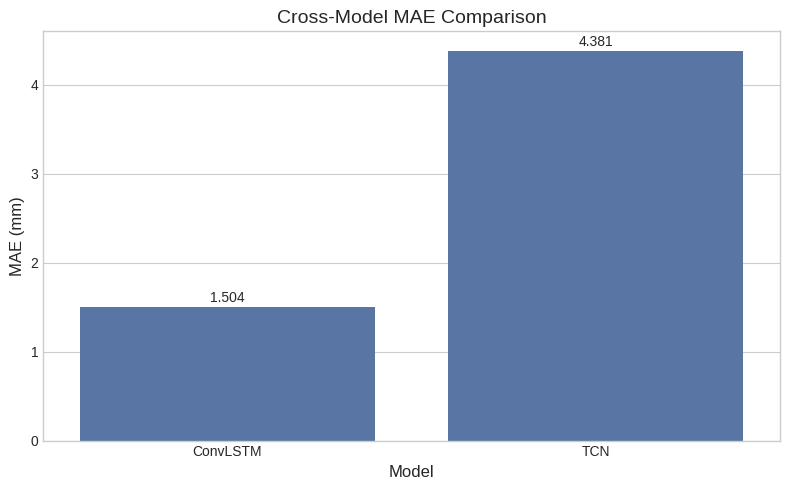

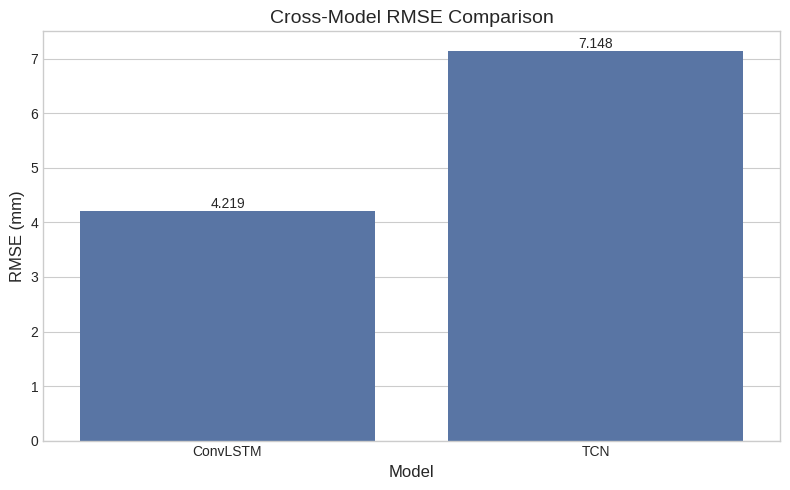

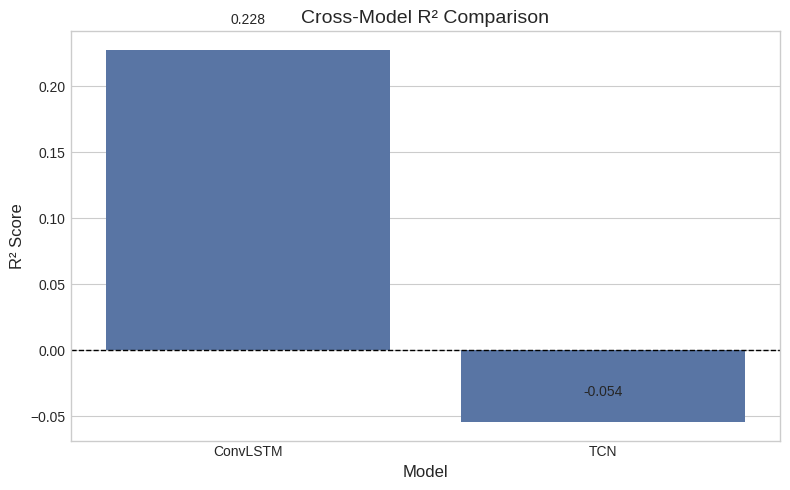

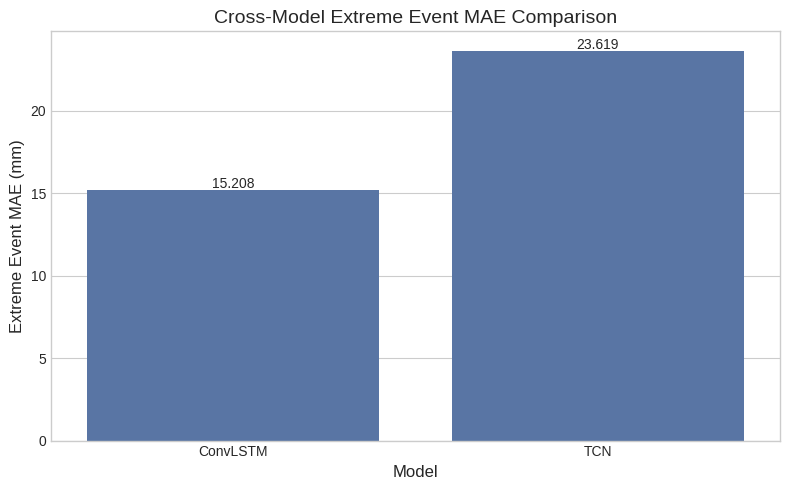

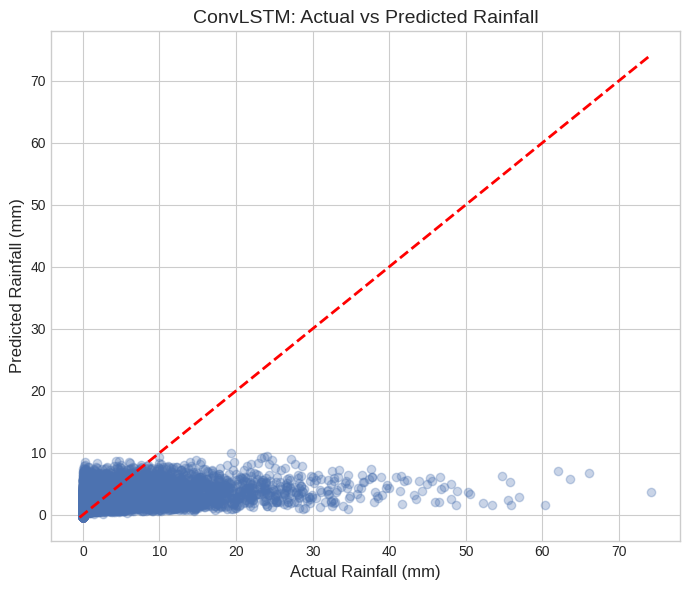

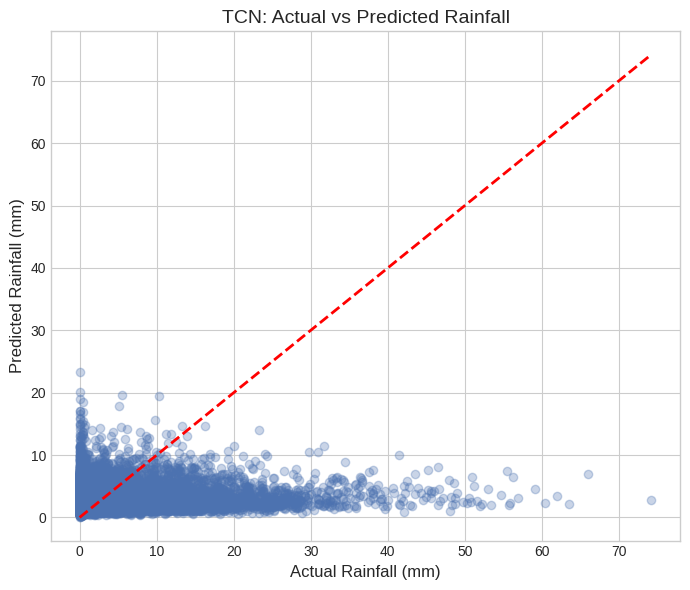

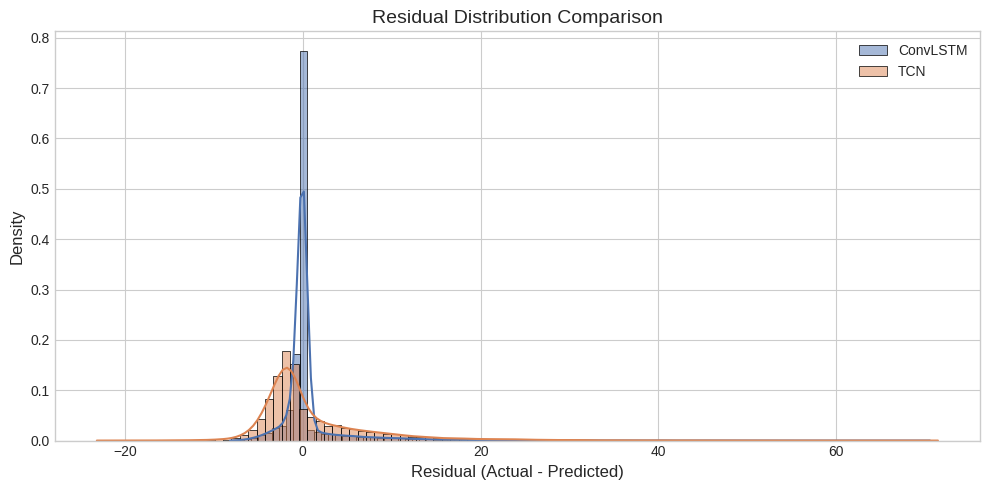

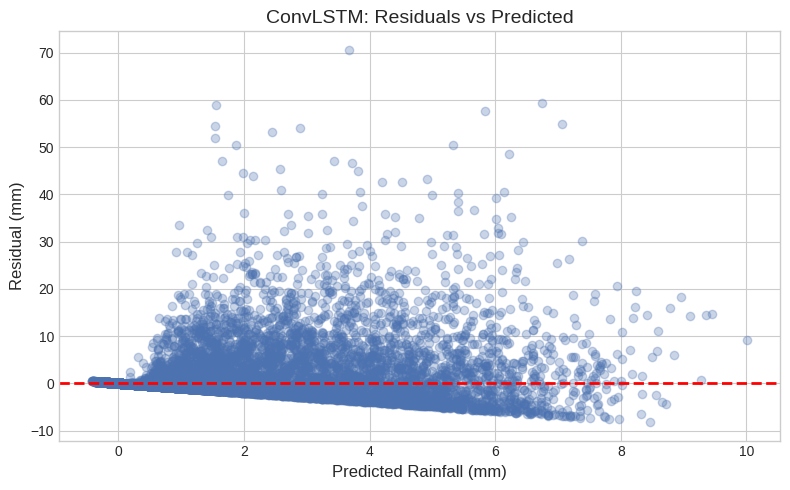

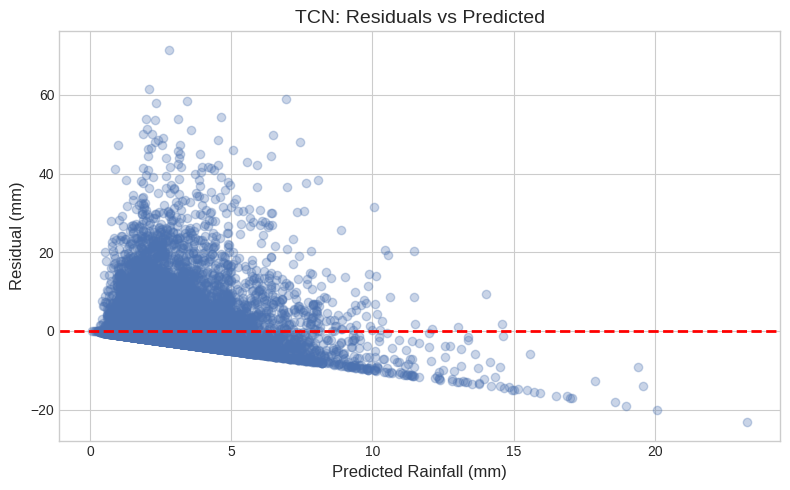

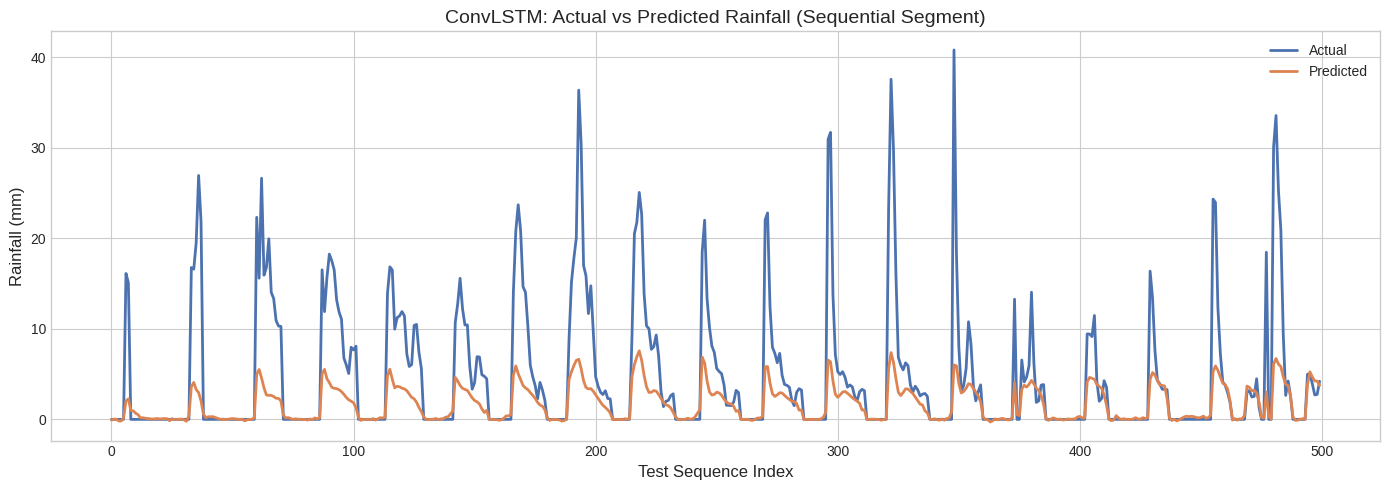

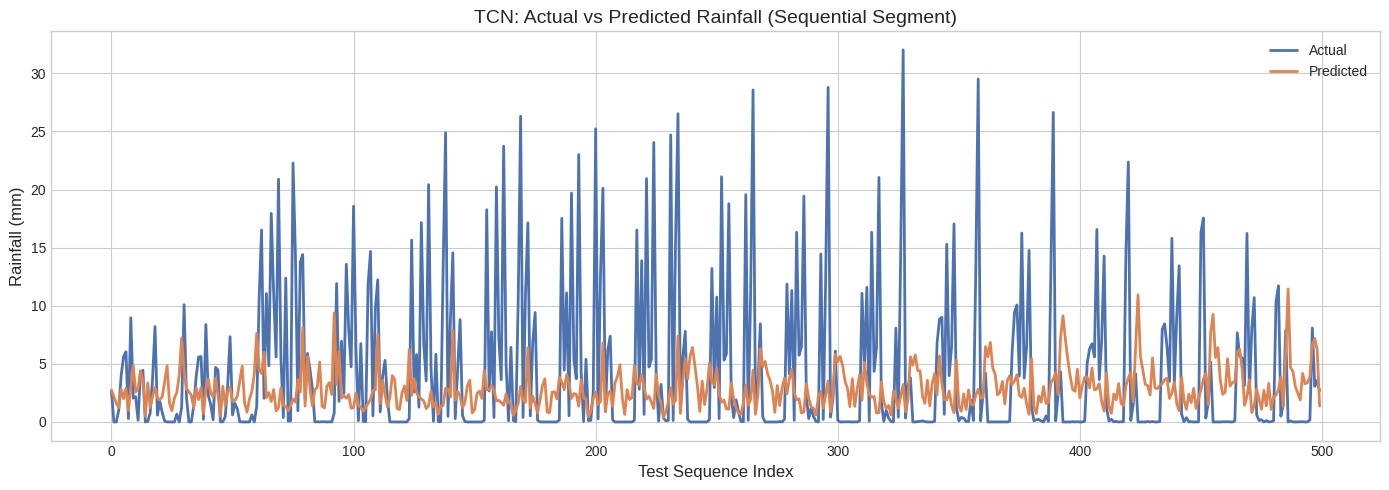

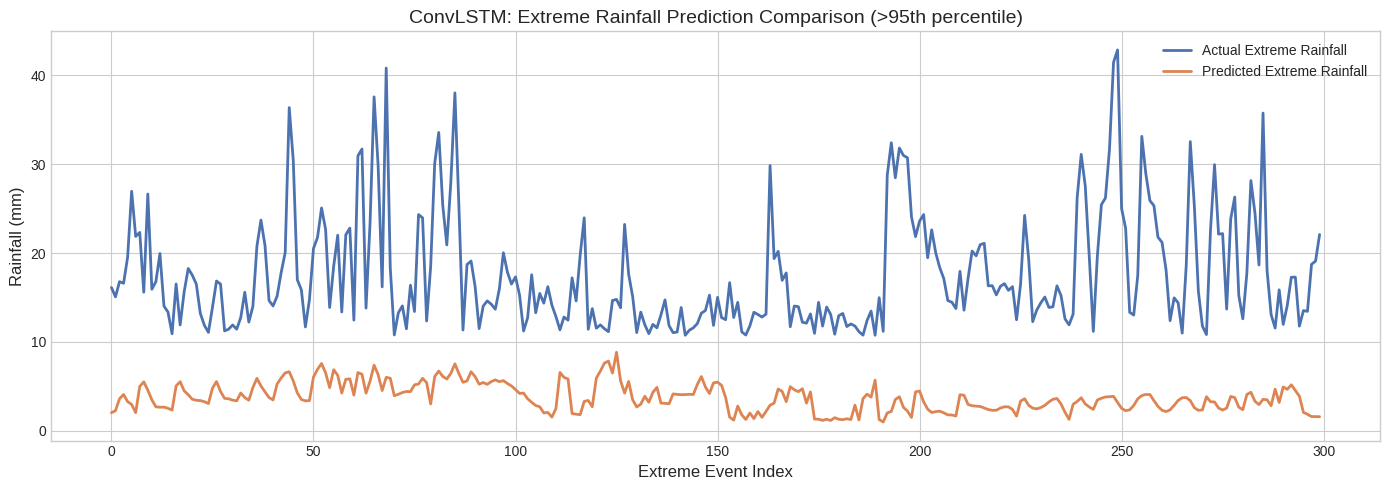

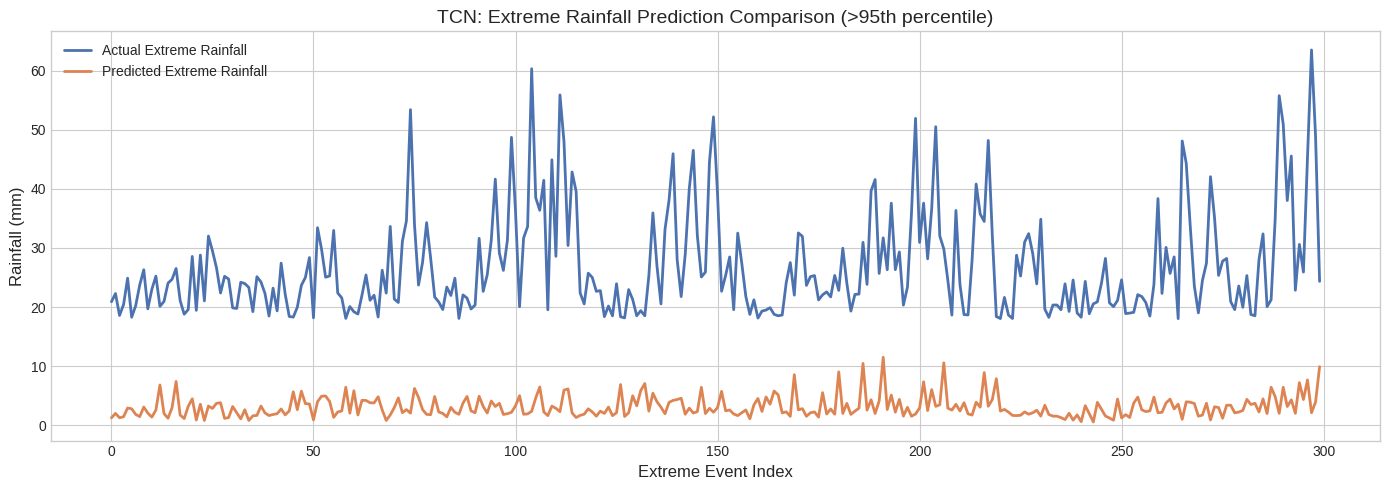

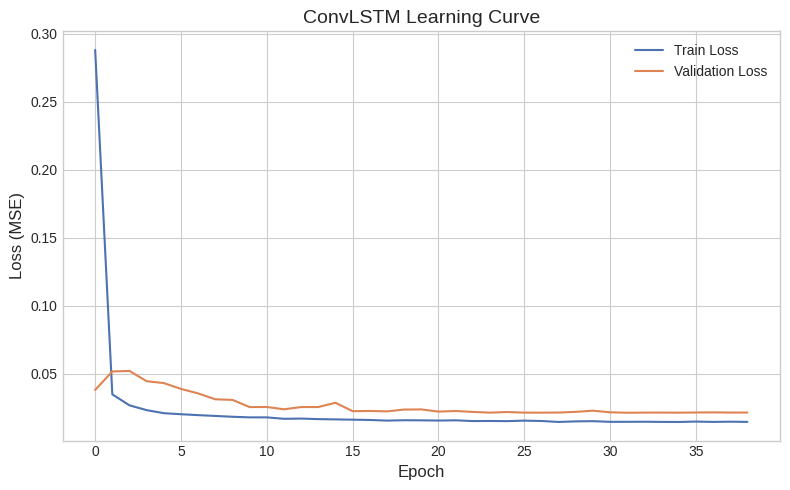

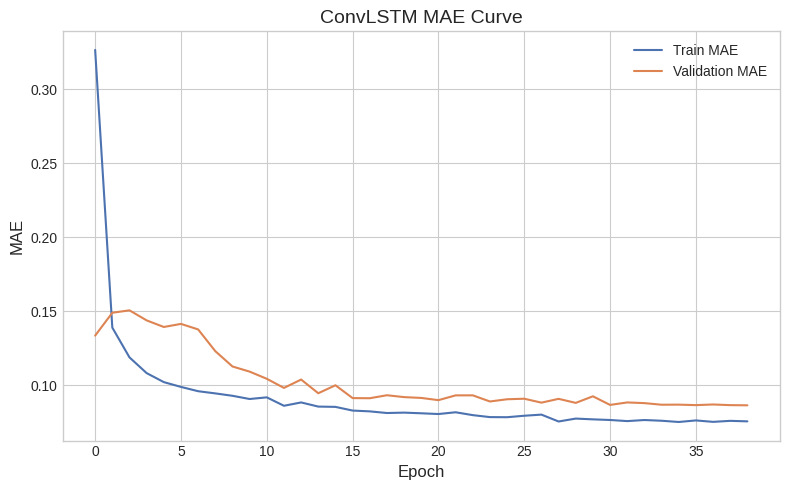

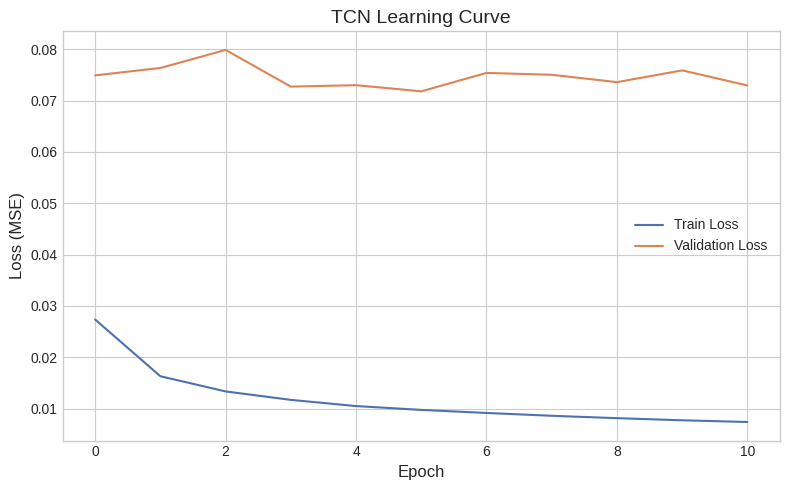

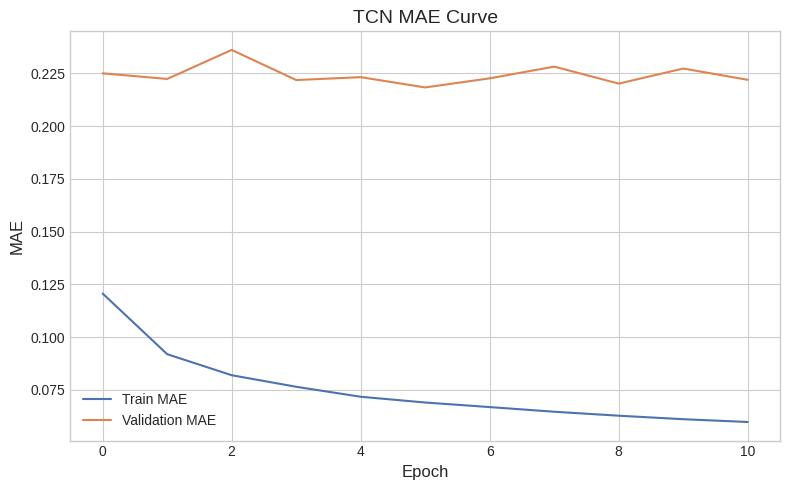

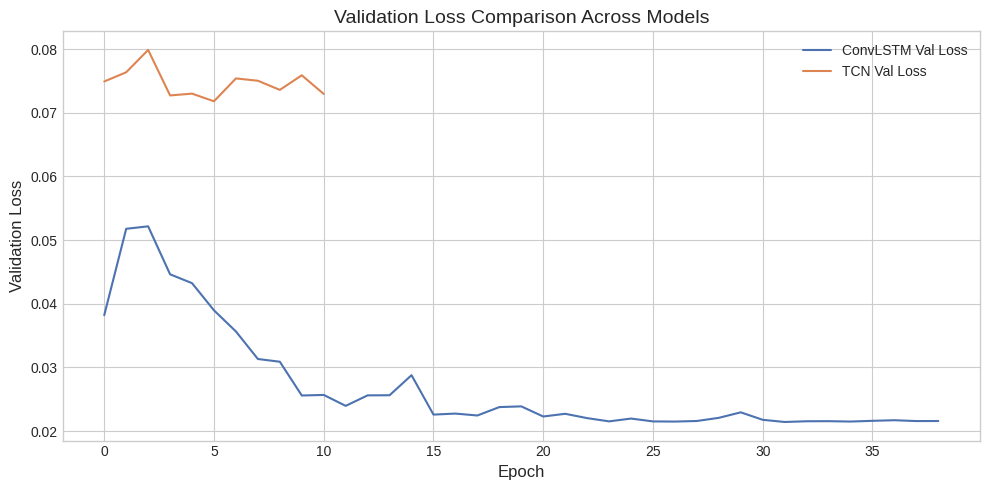

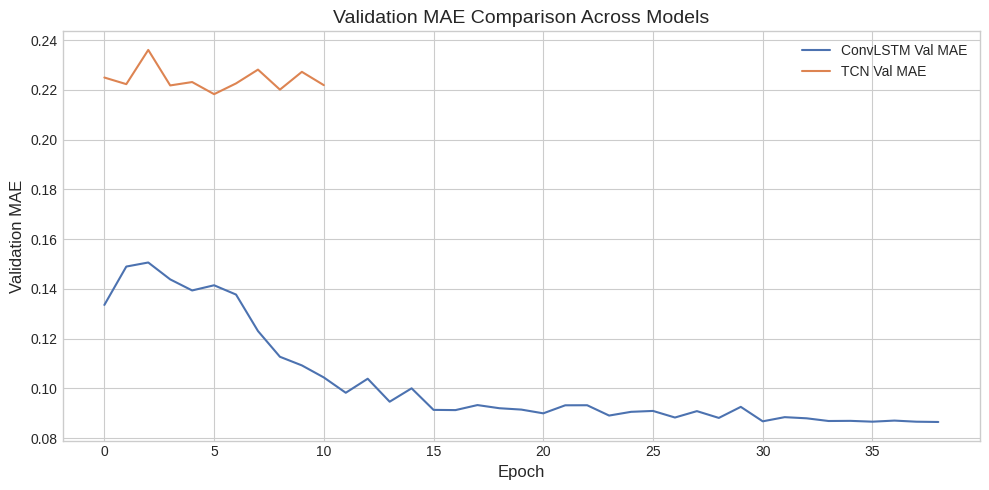


Error Summary Table:


,Model,Mean Error,Median Error,Error Std Dev,Max Absolute Error
0,ConvLSTM,0.6566,-0.0003,4.1677,70.5504
1,TCN,1.1518,-1.1749,7.0543,71.4479



All comparison tables have been generated and saved successfully.


In [ ]:



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")


#ConvLSTM predictions
pred_convlstm = model.predict(X_test)

y_true_convlstm_flat = y_test.flatten()
y_pred_convlstm_flat = pred_convlstm.flatten()

dummy_convlstm = np.zeros((len(y_pred_convlstm_flat), len(FEATURES)))
dummy_convlstm[:, 0] = y_pred_convlstm_flat
inv_pred_convlstm = scaler.inverse_transform(dummy_convlstm)[:, 0]

dummy_convlstm[:, 0] = y_true_convlstm_flat
inv_true_convlstm = scaler.inverse_transform(dummy_convlstm)[:, 0]

pred_convlstm_mm = np.expm1(inv_pred_convlstm)
true_convlstm_mm = np.expm1(inv_true_convlstm)

convlstm_mae = mean_absolute_error(true_convlstm_mm, pred_convlstm_mm)
convlstm_rmse = np.sqrt(mean_squared_error(true_convlstm_mm, pred_convlstm_mm))
convlstm_r2 = r2_score(true_convlstm_mm, pred_convlstm_mm)

convlstm_threshold = np.percentile(true_convlstm_mm, 95)
convlstm_mask_extreme = true_convlstm_mm > convlstm_threshold
convlstm_extreme_mae = mean_absolute_error(
    true_convlstm_mm[convlstm_mask_extreme],
    pred_convlstm_mm[convlstm_mask_extreme]
)

# TCN predictions
pred_tcn_log = tcn_model.predict(X_test_tcn).flatten()

dummy_tcn = np.zeros((len(pred_tcn_log), len(FEATURES)))
dummy_tcn[:, 0] = pred_tcn_log
inv_pred_tcn = scaler.inverse_transform(dummy_tcn)[:, 0]

dummy_tcn[:, 0] = y_test_tcn
inv_true_tcn = scaler.inverse_transform(dummy_tcn)[:, 0]

pred_tcn_mm = np.expm1(inv_pred_tcn)
true_tcn_mm = np.expm1(inv_true_tcn)

tcn_mae = mean_absolute_error(true_tcn_mm, pred_tcn_mm)
tcn_rmse = np.sqrt(mean_squared_error(true_tcn_mm, pred_tcn_mm))
tcn_r2 = r2_score(true_tcn_mm, pred_tcn_mm)

tcn_threshold = np.percentile(true_tcn_mm, 95)
tcn_mask_extreme = true_tcn_mm > tcn_threshold
tcn_extreme_mae = mean_absolute_error(
    true_tcn_mm[tcn_mask_extreme],
    pred_tcn_mm[tcn_mask_extreme]
)


# Model comparison summary table

comparison_df = pd.DataFrame({
    "Model": ["ConvLSTM", "TCN"],
    "MAE_mm": [convlstm_mae, tcn_mae],
    "RMSE_mm": [convlstm_rmse, tcn_rmse],
    "R2": [convlstm_r2, tcn_r2],
    "Extreme_MAE_mm": [convlstm_extreme_mae, tcn_extreme_mae]
})

comparison_df["MAE_Rank"] = comparison_df["MAE_mm"].rank(method="dense")
comparison_df["RMSE_Rank"] = comparison_df["RMSE_mm"].rank(method="dense")
comparison_df["R2_Rank"] = comparison_df["R2"].rank(ascending=False, method="dense")
comparison_df["Extreme_MAE_Rank"] = comparison_df["Extreme_MAE_mm"].rank(method="dense")

comparison_df = comparison_df.sort_values(by=["MAE_mm", "RMSE_mm"]).reset_index(drop=True)

print("\nModel Comparison Table:")
display(comparison_df.round(4))

comparison_df.round(4).to_csv("model_comparison_table.csv", index=False)



final_results_table = comparison_df[[
    "Model", "MAE_mm", "RMSE_mm", "R2", "Extreme_MAE_mm"
]].copy()

final_results_table.columns = [
    "Model", "MAE (mm)", "RMSE (mm)", "R²", "Extreme Event MAE (mm)"
]

print("\nFinal Report Table:")
display(final_results_table.round(4))

final_results_table.round(4).to_csv("final_report_results_table.csv", index=False)

#Cross-model metric comparison plots


# MAE comparison
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x="Model", y="MAE_mm")
plt.title("Cross-Model MAE Comparison")
plt.ylabel("MAE (mm)")
plt.xlabel("Model")
for i, v in enumerate(comparison_df["MAE_mm"]):
    plt.text(i, v + 0.05, f"{v:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

# RMSE comparison
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x="Model", y="RMSE_mm")
plt.title("Cross-Model RMSE Comparison")
plt.ylabel("RMSE (mm)")
plt.xlabel("Model")
for i, v in enumerate(comparison_df["RMSE_mm"]):
    plt.text(i, v + 0.05, f"{v:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

# R2 comparison
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x="Model", y="R2")
plt.title("Cross-Model R² Comparison")
plt.ylabel("R² Score")
plt.xlabel("Model")
for i, v in enumerate(comparison_df["R2"]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)
plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.tight_layout()
plt.show()

# Extreme event MAE comparison
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x="Model", y="Extreme_MAE_mm")
plt.title("Cross-Model Extreme Event MAE Comparison")
plt.ylabel("Extreme Event MAE (mm)")
plt.xlabel("Model")
for i, v in enumerate(comparison_df["Extreme_MAE_mm"]):
    plt.text(i, v + 0.1, f"{v:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

#Actual vs predicted scatter plots


def actual_vs_pred_plot(y_true, y_pred, model_name, sample_size=20000):
    n = min(sample_size, len(y_true))
    idx = np.random.RandomState(42).choice(len(y_true), size=n, replace=False)

    plt.figure(figsize=(7, 6))
    plt.scatter(y_true[idx], y_pred[idx], alpha=0.3)
    min_val = min(y_true[idx].min(), y_pred[idx].min())
    max_val = max(y_true[idx].max(), y_pred[idx].max())
    plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)
    plt.title(f"{model_name}: Actual vs Predicted Rainfall")
    plt.xlabel("Actual Rainfall (mm)")
    plt.ylabel("Predicted Rainfall (mm)")
    plt.tight_layout()
    plt.show()

actual_vs_pred_plot(true_convlstm_mm, pred_convlstm_mm, "ConvLSTM")
actual_vs_pred_plot(true_tcn_mm, pred_tcn_mm, "TCN")

#Residual analysis

convlstm_residuals = true_convlstm_mm - pred_convlstm_mm
tcn_residuals = true_tcn_mm - pred_tcn_mm

# Residual distribution
plt.figure(figsize=(10, 5))
sns.histplot(convlstm_residuals, bins=100, kde=True, label="ConvLSTM", stat="density", alpha=0.5)
sns.histplot(tcn_residuals, bins=100, kde=True, label="TCN", stat="density", alpha=0.5)
plt.title("Residual Distribution Comparison")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# Residual vs predicted
def residual_plot(y_pred, residuals, model_name, sample_size=20000):
    n = min(sample_size, len(y_pred))
    idx = np.random.RandomState(42).choice(len(y_pred), size=n, replace=False)

    plt.figure(figsize=(8, 5))
    plt.scatter(y_pred[idx], residuals[idx], alpha=0.3)
    plt.axhline(0, color="red", linestyle="--", linewidth=2)
    plt.title(f"{model_name}: Residuals vs Predicted")
    plt.xlabel("Predicted Rainfall (mm)")
    plt.ylabel("Residual (mm)")
    plt.tight_layout()
    plt.show()

residual_plot(pred_convlstm_mm, convlstm_residuals, "ConvLSTM")
residual_plot(pred_tcn_mm, tcn_residuals, "TCN")

#Time-ordered comparison plots

def time_series_comparison_plot(y_true, y_pred, model_name, start=0, length=500):
    end = min(start + length, len(y_true))

    plt.figure(figsize=(14, 5))
    plt.plot(y_true[start:end], label="Actual", linewidth=2)
    plt.plot(y_pred[start:end], label="Predicted", linewidth=2)
    plt.title(f"{model_name}: Actual vs Predicted Rainfall (Sequential Segment)")
    plt.xlabel("Test Sequence Index")
    plt.ylabel("Rainfall (mm)")
    plt.legend()
    plt.tight_layout()
    plt.show()

time_series_comparison_plot(true_convlstm_mm, pred_convlstm_mm, "ConvLSTM", start=0, length=500)
time_series_comparison_plot(true_tcn_mm, pred_tcn_mm, "TCN", start=0, length=500)

#Extreme-event prediction comparison

def extreme_event_plot(y_true, y_pred, model_name, percentile=95):
    threshold = np.percentile(y_true, percentile)
    mask = y_true > threshold

    y_true_ext = y_true[mask]
    y_pred_ext = y_pred[mask]

    sample_n = min(300, len(y_true_ext))
    idx = np.arange(sample_n)

    plt.figure(figsize=(14, 5))
    plt.plot(idx, y_true_ext[:sample_n], label="Actual Extreme Rainfall", linewidth=2)
    plt.plot(idx, y_pred_ext[:sample_n], label="Predicted Extreme Rainfall", linewidth=2)
    plt.title(f"{model_name}: Extreme Rainfall Prediction Comparison (>{percentile}th percentile)")
    plt.xlabel("Extreme Event Index")
    plt.ylabel("Rainfall (mm)")
    plt.legend()
    plt.tight_layout()
    plt.show()

extreme_event_plot(true_convlstm_mm, pred_convlstm_mm, "ConvLSTM")
extreme_event_plot(true_tcn_mm, pred_tcn_mm, "TCN")

#Learning curves

# ConvLSTM learning curve
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("ConvLSTM Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")
plt.title("ConvLSTM MAE Curve")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.show()

# TCN learning curve
plt.figure(figsize=(8, 5))
plt.plot(history_tcn.history["loss"], label="Train Loss")
plt.plot(history_tcn.history["val_loss"], label="Validation Loss")
plt.title("TCN Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_tcn.history["mae"], label="Train MAE")
plt.plot(history_tcn.history["val_mae"], label="Validation MAE")
plt.title("TCN MAE Curve")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.show()


#Combined learning curve comparison

plt.figure(figsize=(10, 5))
plt.plot(history.history["val_loss"], label="ConvLSTM Val Loss")
plt.plot(history_tcn.history["val_loss"], label="TCN Val Loss")
plt.title("Validation Loss Comparison Across Models")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["val_mae"], label="ConvLSTM Val MAE")
plt.plot(history_tcn.history["val_mae"], label="TCN Val MAE")
plt.title("Validation MAE Comparison Across Models")
plt.xlabel("Epoch")
plt.ylabel("Validation MAE")
plt.legend()
plt.tight_layout()
plt.show()


#Error summary table


error_summary_df = pd.DataFrame({
    "Model": ["ConvLSTM", "TCN"],
    "Mean Error": [
        np.mean(convlstm_residuals),
        np.mean(tcn_residuals)
    ],
    "Median Error": [
        np.median(convlstm_residuals),
        np.median(tcn_residuals)
    ],
    "Error Std Dev": [
        np.std(convlstm_residuals),
        np.std(tcn_residuals)
    ],
    "Max Absolute Error": [
        np.max(np.abs(convlstm_residuals)),
        np.max(np.abs(tcn_residuals))
    ]
})

print("\nError Summary Table:")
display(error_summary_df.round(4))
error_summary_df.round(4).to_csv("model_error_summary.csv", index=False)

#Save key outputs

comparison_df.to_csv("comparison_metrics_full.csv", index=False)
final_results_table.to_csv("comparison_metrics_report_ready.csv", index=False)
error_summary_df.to_csv("comparison_error_summary.csv", index=False)

print("\nAll comparison tables have been generated and saved successfully.")